# Detecția și clasificarea defectelor la imprimante 3D FDM prin analiza vibrațiilor

Pipeline-ul de învățare automată al lucrării de licență: de la încărcarea datelor brute până la
exportul modelelor folosite de aplicația demonstrativă.

**Date:** set public Szydło et al. (2021), [joanna-/3D-Printing-Data](https://github.com/joanna-/3D-Printing-Data) — imprimantă Delta, două accelerometre, șase stări de funcționare: `proper`, `arm_failure`, `retraction`, `plastic`, `bowden`, `unstick`.

**Etape:** încărcarea și etichetarea datelor, segmentarea în ferestre de 512 eșantioane, extragerea a 90 de caracteristici (domeniul timp și frecvență), antrenarea și evaluarea modelelor prin validare încrucișată pe grupuri (StratifiedGroupKFold, fără scurgere de informație), compararea algoritmilor, analize suplimentare (t-SNE, curbă de învățare, ROC, importanța caracteristicilor, studii de sensibilitate) și exportul modelelor.

**Model final:** Random Forest pe 90 de caracteristici, acuratețe 81,71% ± 7,04% prin validare pe grupuri.

## 1. Setup

Instalarea pachetelor (o singură dată; pe Google Colab majoritatea sunt deja disponibile).

In [ ]:
!pip install pandas numpy matplotlib scipy scikit-learn seaborn joblib -q

### Import-uri și parametri globali

In [ ]:
import os
import time
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kurtosis, skew

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    StratifiedGroupKFold,
    cross_val_score,
    cross_val_predict,
    learning_curve,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc,
)

import joblib

GRAFICE_DIR = 'grafice'
os.makedirs(GRAFICE_DIR, exist_ok=True)

WINDOW_SIZE = 512
N_BLOCKS_PER_CLASS = 10
AXES = ['acc1_x', 'acc1_y', 'acc1_z', 'acc2_x', 'acc2_y', 'acc2_z']
RANDOM_STATE = 42

CULORI = {
    'arm_failure': '#7F77DD', 'bowden': '#1D9E75', 'plastic': '#D85A30',
    'proper': '#D4537E',      'retraction': '#378ADD', 'unstick': '#BA7517',
}

Toate bibliotecile au fost importate cu succes.


## 2. Descărcarea datelor

Clonarea depozitului public (o singură dată). Conține fișiere `.zip` cu înregistrări de vibrație pentru fiecare clasă.

In [ ]:
!git clone https://github.com/joanna-/3D-Printing-Data.git

Cloning into '3D-Printing-Data'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 122 (delta 2), reused 2 (delta 0), pack-reused 116 (from 1)
Receiving objects: 100% (122/122), 239.37 MiB | 18.62 MiB/s, done.
Resolving deltas: 100% (31/31), done.
Updating files: 100% (21/21), done.


### Dezarhivarea fișierelor în folderul `four_towers`.

In [ ]:
!find 3D-Printing-Data/four_towers -name "*.zip" -exec unzip -q {} -d {}_extracted \;
print('Dezarhivare completa.')

Dezarhivare completa.


## 3. Încărcarea datelor

Fiecare fișier `.txt` conține înregistrări continue de la două accelerometre triaxiale; se folosesc doar canalele de accelerație (`acc1_*`, `acc2_*`). Structura coloanelor diferă ușor între clase (fișierul clasei `arm_failure` are o coloană de index în plus), de aceea încărcarea detectează numărul de coloane și aliniază canalele corespunzător.

Coloane: `data_id`, `acc1_x/y/z` (senzor 1 — pat), `acc2_x/y/z` (senzor 2 — cap), `tension` (neutilizată) și `timestamp`. Datele sunt concatenate într-un singur `DataFrame`, etichetate pe clase.

In [ ]:
def incarca_fisier(path, label):
    raw = pd.read_csv(path, header=None, low_memory=False)
    n = raw.shape[1]
    if n == 10:        # format arm_failure (o coloana 'index' in plus la inceput)
        names = ['rowidx','data_id','acc1_x','acc1_y','acc1_z',
                 'acc2_x','acc2_y','acc2_z','tension','timestamp']
    elif n == 9:       # format standard (restul claselor)
        names = ['data_id','acc1_x','acc1_y','acc1_z',
                 'acc2_x','acc2_y','acc2_z','tension','timestamp']
    else:
        raise ValueError(f'{label}: {n} coloane neasteptat - verifica manual')
    raw.columns = names
    raw['label'] = label
    return raw

fisiere = {
    'arm_failure': '3D-Printing-Data/four_towers/arm_failure/arm_failure.zip_extracted/head_arm_failure.txt',
    'retraction':  '3D-Printing-Data/four_towers/retraction/retraction_05.zip_extracted/retraction_05.txt',
    'proper':      '3D-Printing-Data/four_towers/proper/proper.zip_extracted/proper/accel.txt',
    'plastic':     '3D-Printing-Data/four_towers/plastic/plastic.zip_extracted/plastic/accel_plastic.txt',
    'bowden':      '3D-Printing-Data/four_towers/bowden/bowden.zip_extracted/bowden/bowden_accel.txt',
    'unstick':     '3D-Printing-Data/four_towers/unstick/unstick.zip_extracted/unstick/accel_unstick.txt',
}

dfs = []
for label, path in fisiere.items():
    df = incarca_fisier(path, label)
    dfs.append(df)
    print(f'{label}: {len(df):,} randuri, {df.shape[1]} coloane')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\nTOTAL: {len(df_all):,} randuri')
print('\nDistributie clase:')
print(df_all['label'].value_counts())

arm_failure: 826,126 randuri, 11 coloane
retraction: 1,672,290 randuri, 10 coloane
proper: 1,509,510 randuri, 10 coloane
plastic: 302,739 randuri, 10 coloane
bowden: 354,827 randuri, 10 coloane
unstick: 1,673,747 randuri, 10 coloane

TOTAL: 6,339,239 randuri

Distributie clase:
label
unstick        1673747
retraction     1672290
proper         1509510
arm_failure     826126
bowden          354827
plastic         302739
Name: count, dtype: int64


In [ ]:
for lab in df_all['label'].unique():
    d = df_all[df_all['label'] == lab]
    az1 = pd.to_numeric(d['acc1_z'], errors='coerce').mean()
    az2 = pd.to_numeric(d['acc2_z'], errors='coerce').mean()
    tn  = pd.to_numeric(d['tension'], errors='coerce').mean()
    print(f'{lab:12s}  acc1_z={az1:7.3f}  acc2_z={az2:7.3f}  tension={tn:8.1f}')

arm_failure   acc1_z=  9.666  acc2_z= -9.826  tension=  3516.0
retraction    acc1_z=  9.656  acc2_z= -9.822  tension=  3481.8
proper        acc1_z=  9.615  acc2_z= -9.900  tension=  3366.1
plastic       acc1_z=  9.985  acc2_z= -9.813  tension=  3348.2
bowden        acc1_z=  9.671  acc2_z= -9.794  tension=  2883.3
unstick       acc1_z=  9.632  acc2_z= -9.856  tension=  3401.5


## 4. Vizualizare: distribuția claselor

Primul grafic din lucrare — arată cât de dezechilibrat e dataset-ul (`plastic` are doar ~300k rânduri vs `unstick` cu 1.6M). Pentru asta voi folosi `class_weight='balanced'` mai târziu în Random Forest.

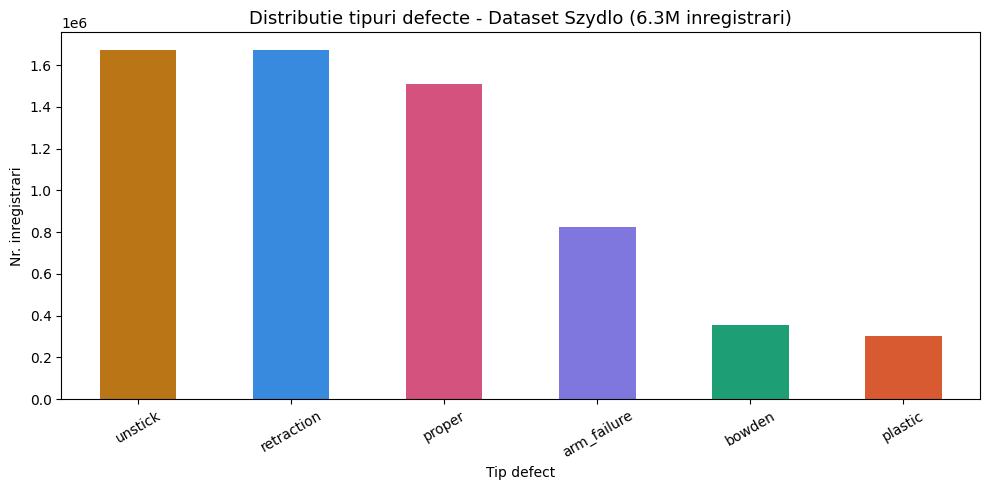

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = [CULORI[c] for c in df_all['label'].value_counts().index]
df_all['label'].value_counts().plot(kind='bar', ax=ax, color=colors)
ax.set_title('Distributie tipuri defecte - Dataset Szydlo (6.3M inregistrari)', fontsize=13)
ax.set_xlabel('Tip defect')
ax.set_ylabel('Nr. inregistrari')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICE_DIR, 'distributie_clase.png'), dpi=150)
plt.show()

## 5. Vizualizare: vibrații în domeniul timp

Pentru fiecare clasă arat o fereastră scurtă de accelerație (axa Z senzor 1). Vizual se vede că fiecare defect are o **amprentă distinctă** — motivul pentru care un algoritm de ML poate învăța să le distinge.

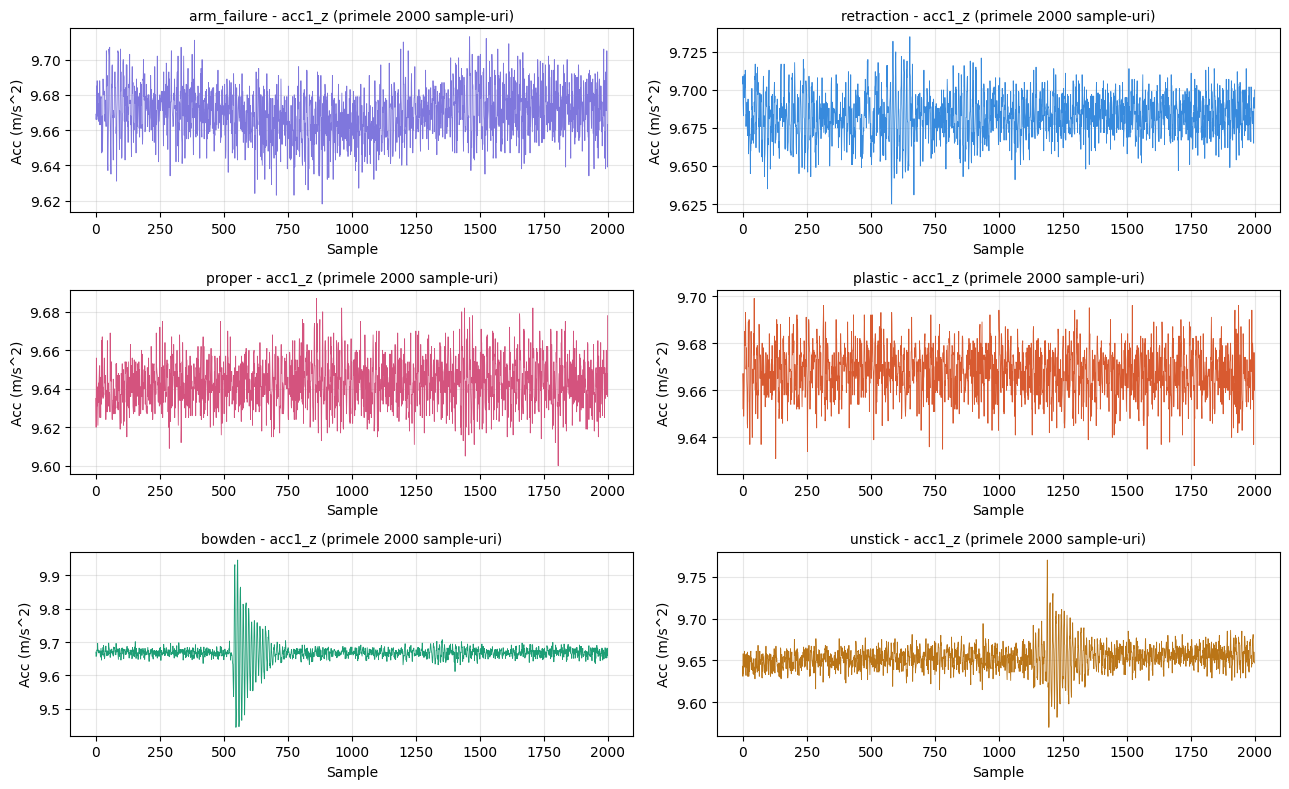

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 8))
axes = axes.flatten()

for i, cls in enumerate(df_all['label'].unique()):
    subset = df_all[df_all['label'] == cls]['acc1_z'].dropna().values[:2000]
    subset = pd.to_numeric(pd.Series(subset), errors='coerce').dropna().values
    axes[i].plot(subset[:2000], color=CULORI[cls], linewidth=0.6)
    axes[i].set_title(f'{cls} - acc1_z (primele 2000 sample-uri)', fontsize=10)
    axes[i].set_xlabel('Sample')
    axes[i].set_ylabel('Acc (m/s^2)')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(GRAFICE_DIR, 'vibratii_timp.png'), dpi=150)
plt.show()

## 6. Vizualizare: FFT comparativ

Același lucru ca mai sus, dar în **domeniul frecvenței** (transform Fourier rapid). Aici se vede că fiecare clasă are vârfuri spectrale diferite — ce înseamnă că caracteristicile FFT vor fi puternice pentru clasificare.

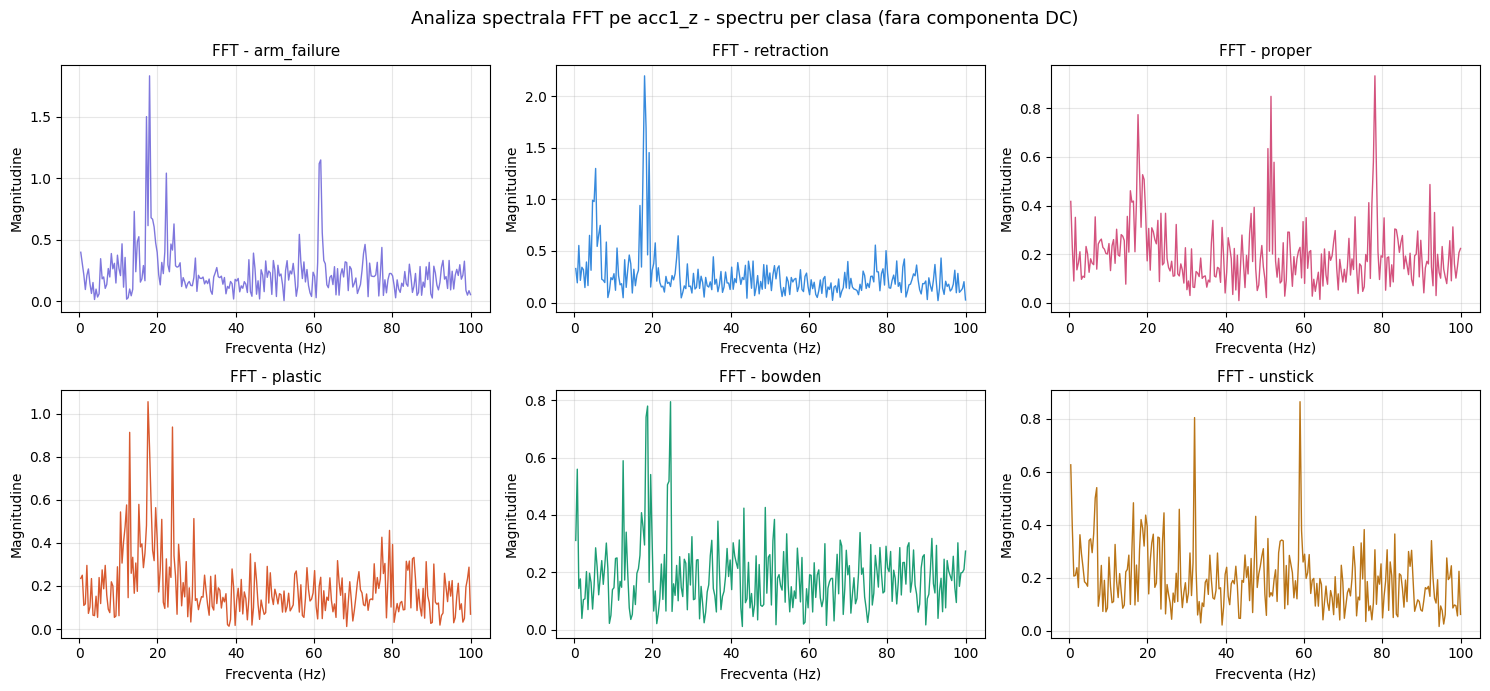

In [ ]:
fs = 200  # frecventa de esantionare a dataset-ului (Szydlo et al. 2021)
freqs = np.fft.rfftfreq(WINDOW_SIZE, d=1/fs)

clase = df_all['label'].unique()
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

for i, cls in enumerate(clase):
    subset = pd.to_numeric(df_all[df_all['label'] == cls]['acc1_z'],
                           errors='coerce').dropna().values[:WINDOW_SIZE]
    if len(subset) < WINDOW_SIZE:
        continue
    fft_vals = np.abs(np.fft.rfft(subset))
    # excludem bin 0 (componenta DC / gravitatie) ca sa se vada vibratia
    axes[i].plot(freqs[1:], fft_vals[1:], color=CULORI.get(cls), linewidth=1.0)
    axes[i].set_title(f'FFT - {cls}', fontsize=11)
    axes[i].set_xlabel('Frecventa (Hz)')
    axes[i].set_ylabel('Magnitudine')
    axes[i].grid(alpha=0.3)

plt.suptitle('Analiza spectrala FFT pe acc1_z - spectru per clasa (fara componenta DC)',
             fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICE_DIR, 'fft_comparativ.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Extragere caracteristici (66 features)

**Pasul cheie de signal processing.** Convertesc semnalul brut (n·56 milioane de sample-uri) în caracteristici compacte care să descrie fiecare fereastră de 512 sample-uri.

**Pentru fiecare fereastră în fiecare axă (din 6 axe):** 11 caracteristici
- Statistici temporale: `mean, std, max(|x|), min`
- Statistici FFT: `mean, max, freq_dominanta, energie totala`
- Energie pe benzi de frecvență: `joase (0-10), medii (10-50), inalte (50+)`

Total: **11 caracteristici × 6 axe = 66 features per fereastră.**

In [ ]:
def extract_features_66(df, window_size=WINDOW_SIZE):
    features, labels = [], []

    for label in df['label'].unique():
        subset = df[df['label'] == label][AXES].copy()
        for ax in AXES:
            subset[ax] = pd.to_numeric(subset[ax], errors='coerce')
        subset = subset.dropna().values.astype(np.float64)

        for i in range(0, len(subset) - window_size, window_size):
            window = subset[i:i+window_size]
            feat = []
            for ax_idx in range(6):
                ax_data = window[:, ax_idx]
                fft_vals = np.abs(np.fft.rfft(ax_data))
                feat += [
                    np.mean(ax_data), np.std(ax_data),
                    np.max(np.abs(ax_data)), np.min(ax_data),
                    np.mean(fft_vals), np.max(fft_vals),
                    float(np.argmax(fft_vals)), np.sum(fft_vals**2),
                    np.sum(fft_vals[:10]), np.sum(fft_vals[10:50]),
                    np.sum(fft_vals[50:]),
                ]
            features.append(feat)
            labels.append(label)
    return np.array(features), np.array(labels)

print('Extrag caracteristici (66 features)... dureaza 2-3 minute')
X, y = extract_features_66(df_all)
print(f'Shape X: {X.shape}')
print(f'Etichete unice: {pd.Series(y).value_counts().to_dict()}')

Extrag caracteristici (66 features)... dureaza 2-3 minute
Shape X: (12380, 66)
Etichete unice: {'unstick': 3269, 'retraction': 3266, 'proper': 2948, 'arm_failure': 1613, 'bowden': 693, 'plastic': 591}


## 8. Împărțire naivă: train/test split clasic (cu data leakage)

Random Forest este antrenat cu o împărțire train/test 80/20 amestecată aleator. **Acesta este pasul care introduce data leakage**: ferestre consecutive din aceeași înregistrare ajung atât în antrenare, cât și în test.

Acuratețea ridicată rezultată (peste 90%) este prezentată aici pentru a demonstra problema, corectată în secțiunea următoare prin Block-CV.

In [ ]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {len(X_train)} ferestre')
print(f'Test:  {len(X_test)} ferestre')

rf_naive = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_naive.fit(X_train_scaled, y_train)
y_pred = rf_naive.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f'\n[NAIV - cu data leakage] Random Forest Accuracy: {acc*100:.2f}%')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=3))
print('\n>>> AVERTISMENT: acest rezultat este nerealist din cauza data leakage <<<')

Train: 9904 ferestre
Test:  2476 ferestre

[NAIV - cu data leakage] Random Forest Accuracy: 94.02%

Classification report:
              precision    recall  f1-score   support

 arm_failure      0.911     0.889     0.900       323
      bowden      0.909     0.791     0.846       139
     plastic      0.922     0.797     0.855       118
      proper      0.973     0.990     0.981       589
  retraction      0.928     0.965     0.946       653
     unstick      0.945     0.954     0.950       654

    accuracy                          0.940      2476
   macro avg      0.931     0.898     0.913      2476
weighted avg      0.940     0.940     0.939      2476


>>> AVERTISMENT: acest rezultat este nerealist din cauza data leakage <<<


## 9. Descoperirea data leakage: Block-CV (StratifiedGroupKFold)

**Pasul metodologic al lucrării.**

Setul de date conține **înregistrări continue per clasă**. Ferestrele FFT consecutive sunt practic identice fizic. Când `StratifiedKFold(shuffle=True)` le amestecă, ferestrele adiacente temporal ajung și la train și la test — modelul învață amprenta înregistrării, nu a defectului.

**Soluția:** Împart fiecare înregistrare în 10 blocuri temporale contigue. Folosesc `StratifiedGroupKFold` care garantează că blocurile (deci ferestrele apropiate temporal) **NU sunt împărțite** între train și test.

Compar:
- `StratifiedKFold` cu shuffle — versiunea cu leakage
- `StratifiedGroupKFold` pe blocuri — versiunea corectă

Diferența dintre cele două acurateți (afișată mai jos) este **dovada cuantificată a leakage-ului**.

In [ ]:
features, labels, groups = [], [], []

for label in df_all['label'].unique():
    subset = df_all[df_all['label'] == label][AXES].copy()
    for ax in AXES:
        subset[ax] = pd.to_numeric(subset[ax], errors='coerce')
    subset = subset.dropna().values.astype(np.float64)

    starts = list(range(0, len(subset) - WINDOW_SIZE, WINDOW_SIZE))
    windows_per_block = max(1, len(starts) // N_BLOCKS_PER_CLASS)

    for win_idx, start in enumerate(starts):
        window = subset[start:start + WINDOW_SIZE]
        feat = []
        for ax_idx in range(6):
            ax_data = window[:, ax_idx]
            fft_vals = np.abs(np.fft.rfft(ax_data))
            feat += [
                np.mean(ax_data), np.std(ax_data),
                np.max(np.abs(ax_data)), np.min(ax_data),
                np.mean(fft_vals), np.max(fft_vals),
                float(np.argmax(fft_vals)), np.sum(fft_vals**2),
                np.sum(fft_vals[:10]), np.sum(fft_vals[10:50]),
                np.sum(fft_vals[50:]),
            ]

        block_id = min(win_idx // windows_per_block, N_BLOCKS_PER_CLASS - 1)
        features.append(feat)
        labels.append(label)
        groups.append(f'{label}_b{block_id}')

X_blk = np.array(features)
y_blk = np.array(labels)
groups_blk = np.array(groups)
le_blk = LabelEncoder()
y_blk_enc = le_blk.fit_transform(y_blk)

print(f'Features shape: {X_blk.shape}')
print(f'Grupuri unice totale: {len(set(groups_blk))}  (~10 per clasa)')

rf_eval = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)

print('\n' + '='*72)
print('COMPARATIE: leakage vs. validare corecta')
print('='*72)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_skf = cross_val_score(rf_eval, X_blk, y_blk_enc, cv=skf,
                             scoring='accuracy', n_jobs=-1)
print('\n[ORIGINAL - StratifiedKFold cu shuffle (leakage prezent)]')
print(f'  Folduri: {np.round(scores_skf*100, 2)}')
print(f'  Mean:    {scores_skf.mean()*100:.2f}% +/- {scores_skf.std()*100:.2f}%')

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_sgkf = cross_val_score(rf_eval, X_blk, y_blk_enc, groups=groups_blk,
                              cv=sgkf, scoring='accuracy', n_jobs=-1)
print('\n[CORECT - StratifiedGroupKFold pe blocuri temporale]')
print(f'  Folduri: {np.round(scores_sgkf*100, 2)}')
print(f'  Mean:    {scores_sgkf.mean()*100:.2f}% +/- {scores_sgkf.std()*100:.2f}%')

delta = (scores_skf.mean() - scores_sgkf.mean()) * 100
print(f'\n>>> Optimismul cauzat de leakage: +{delta:.2f} puncte procentuale <<<')

y_pred_blk = cross_val_predict(rf_eval, X_blk, y_blk_enc,
                                groups=groups_blk, cv=sgkf, n_jobs=-1)
print('\nClassification report (Block-CV):')
print(classification_report(y_blk_enc, y_pred_blk,
                            target_names=le_blk.classes_, digits=3))

Features shape: (12380, 66)
Grupuri unice totale: 60  (~10 per clasa)

COMPARATIE: leakage vs. validare corecta

[ORIGINAL - StratifiedKFold cu shuffle (leakage prezent)]
  Folduri: [94.43 94.83 94.47 95.07 94.59]
  Mean:    94.68% +/- 0.24%

[CORECT - StratifiedGroupKFold pe blocuri temporale]
  Folduri: [88.06 91.43 73.82 83.1  70.67]
  Mean:    81.42% +/- 8.01%

>>> Optimismul cauzat de leakage: +13.26 puncte procentuale <<<

Classification report (Block-CV):
              precision    recall  f1-score   support

 arm_failure      0.707     0.728     0.718      1613
      bowden      0.573     0.534     0.553       693
     plastic      0.400     0.575     0.472       591
      proper      0.934     0.927     0.931      2948
  retraction      0.882     0.830     0.855      3266
     unstick      0.868     0.855     0.861      3269

    accuracy                          0.818     12380
   macro avg      0.727     0.742     0.732     12380
weighted avg      0.827     0.818     0.822  

## 10. Model îmbunătățit — 90 features

Adaug caracteristici suplimentare specifice analizei de vibrații în mentenanță predictivă:
- **RMS** (Root Mean Square) — energia medie a semnalului
- **Kurtosis** — sensibilitate la spike-uri (impulsuri/vârfuri ascunse)
- **Crest factor** — raport max/RMS, indică impulsuri
- **Skewness** — asimetria distribuției

Total: **15 caracteristici × 6 axe = 90 features per fereastră.**

Folosesc `class_weight='balanced'` ca să compensez dezechilibrul claselor (`plastic` are doar 591 ferestre vs `unstick` cu 3269).

Total features per fereastra: 90 (15 stats x 6 axe)
X_full shape: (12380, 90)

MODEL IMBUNATATIT - StratifiedGroupKFold
Folduri:  [86.48 91.55 73.14 82.47 71.85]
Accuracy: 81.10% +/- 7.60%

Classification report:
              precision    recall  f1-score   support

 arm_failure      0.711     0.727     0.719      1613
      bowden      0.526     0.547     0.536       693
     plastic      0.402     0.570     0.471       591
      proper      0.941     0.917     0.929      2948
  retraction      0.871     0.822     0.846      3266
     unstick      0.871     0.856     0.863      3269

    accuracy                          0.814     12380
   macro avg      0.720     0.740     0.727     12380
weighted avg      0.825     0.814     0.818     12380



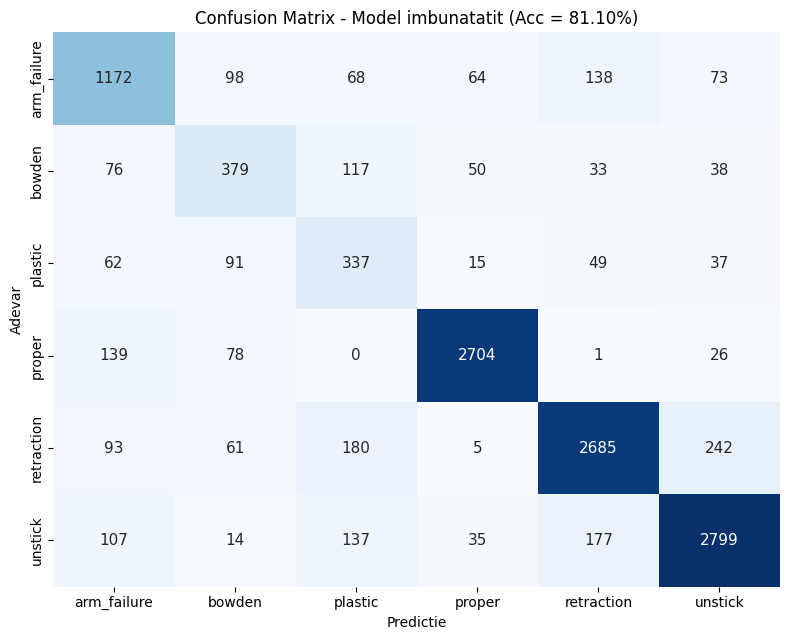

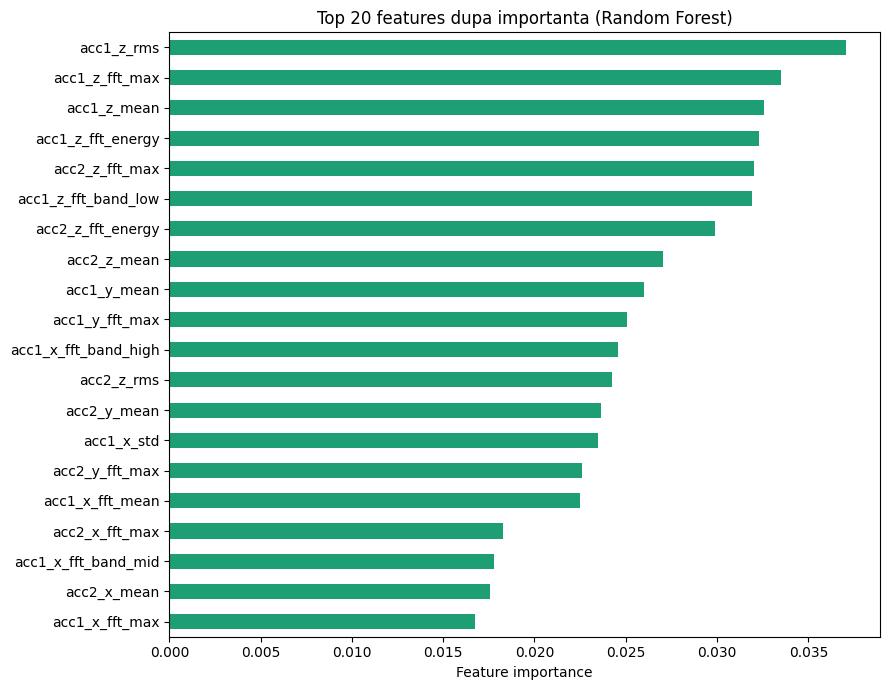

In [ ]:
FEATURE_NAMES_PER_AXIS = [
    'mean', 'std', 'max_abs', 'min',
    'rms', 'kurtosis', 'crest_factor', 'skewness',
    'fft_mean', 'fft_max', 'fft_dom_freq', 'fft_energy',
    'fft_band_low', 'fft_band_mid', 'fft_band_high',
]
FEATURE_NAMES = [f'{ax}_{stat}' for ax in AXES for stat in FEATURE_NAMES_PER_AXIS]
print(f'Total features per fereastra: {len(FEATURE_NAMES)} ({len(FEATURE_NAMES_PER_AXIS)} stats x {len(AXES)} axe)')

features, labels, groups = [], [], []

for label in df_all['label'].unique():
    subset = df_all[df_all['label'] == label][AXES].copy()
    for ax in AXES:
        subset[ax] = pd.to_numeric(subset[ax], errors='coerce')
    subset = subset.dropna().values.astype(np.float64)

    starts = list(range(0, len(subset) - WINDOW_SIZE, WINDOW_SIZE))
    windows_per_block = max(1, len(starts) // N_BLOCKS_PER_CLASS)

    for win_idx, start in enumerate(starts):
        window = subset[start:start + WINDOW_SIZE]
        feat = []
        for ax_idx in range(6):
            ax_data = window[:, ax_idx]
            abs_ax = np.abs(ax_data)
            rms = np.sqrt(np.mean(ax_data ** 2))
            crest = abs_ax.max() / (rms + 1e-9)
            fft_vals = np.abs(np.fft.rfft(ax_data))

            feat += [
                np.mean(ax_data), np.std(ax_data),
                abs_ax.max(), ax_data.min(),
                rms, kurtosis(ax_data),
                crest, skew(ax_data),
                np.mean(fft_vals), np.max(fft_vals),
                float(np.argmax(fft_vals)), np.sum(fft_vals ** 2),
                np.sum(fft_vals[:10]), np.sum(fft_vals[10:50]),
                np.sum(fft_vals[50:]),
            ]

        block_id = min(win_idx // windows_per_block, N_BLOCKS_PER_CLASS - 1)
        features.append(feat)
        labels.append(label)
        groups.append(f'{label}_b{block_id}')

X_full = np.array(features)
y_full = np.array(labels)
groups_full = np.array(groups)
le_full = LabelEncoder()
y_full_enc = le_full.fit_transform(y_full)

print(f'X_full shape: {X_full.shape}')

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(rf_final, X_full, y_full_enc, groups=groups_full,
                         cv=sgkf, scoring='accuracy', n_jobs=-1)

print('\n' + '='*60)
print('MODEL IMBUNATATIT - StratifiedGroupKFold')
print('='*60)
print(f'Folduri:  {np.round(scores*100, 2)}')
print(f'Accuracy: {scores.mean()*100:.2f}% +/- {scores.std()*100:.2f}%')

y_pred_full = cross_val_predict(rf_final, X_full, y_full_enc,
                                 groups=groups_full, cv=sgkf, n_jobs=-1)
print('\nClassification report:')
print(classification_report(y_full_enc, y_pred_full,
                            target_names=le_full.classes_, digits=3))

cm = confusion_matrix(y_full_enc, y_pred_full)
cm_df = pd.DataFrame(cm, index=le_full.classes_, columns=le_full.classes_)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={'size': 11}, ax=ax)
ax.set_title(f'Confusion Matrix - Model imbunatatit (Acc = {scores.mean()*100:.2f}%)', fontsize=12)
ax.set_xlabel('Predictie')
ax.set_ylabel('Adevar')
plt.tight_layout()
plt.savefig(os.path.join(GRAFICE_DIR, 'confusion_matrix_final.png'), dpi=150)
plt.show()

rf_final.fit(X_full, y_full_enc)
importances = pd.Series(rf_final.feature_importances_, index=FEATURE_NAMES)
top20 = importances.sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
top20.plot(kind='barh', color='#1D9E75', ax=ax)
ax.set_title('Top 20 features dupa importanta (Random Forest)', fontsize=12)
ax.set_xlabel('Feature importance')
plt.tight_layout()
plt.savefig(os.path.join(GRAFICE_DIR, 'feature_importance.png'), dpi=150)
plt.show()

## 10b. Model final — hiperparametri optimizați

Hiperparametrii Random Forest au fost optimizați anterior prin căutare în grilă (`GridSearchCV`, cu același Block-CV). Configurația câștigătoare: `n_estimators=300`, `max_depth=None`, `min_samples_leaf=1`.

Celula de mai jos folosește direct acești parametri (nu re-rulează căutarea, ca să fie rapidă) și:
- recalculează acuratețea prin Block-CV,
- regenerează matricea de confuzie și graficul de importanță a caracteristicilor,
- **unifică** restul notebook-ului pe cele 90 features (`X_blk = X_full`), astfel încât toate analizele care urmează (comparație, t-SNE, learning curve, ROC) folosesc același set de caracteristici.

Acesta este modelul a cărui performanță (**81,71% ± 7,04%**) este raportată în lucrare.

Acuratete block-CV: 81.71% +/- 7.04%
              precision    recall  f1-score   support

 arm_failure      0.714     0.741     0.727      1613
      bowden      0.560     0.515     0.537       693
     plastic      0.421     0.547     0.475       591
      proper      0.940     0.925     0.932      2948
  retraction      0.861     0.833     0.847      3266
     unstick      0.872     0.864     0.868      3269

    accuracy                          0.820     12380
   macro avg      0.728     0.738     0.731     12380
weighted avg      0.826     0.820     0.822     12380



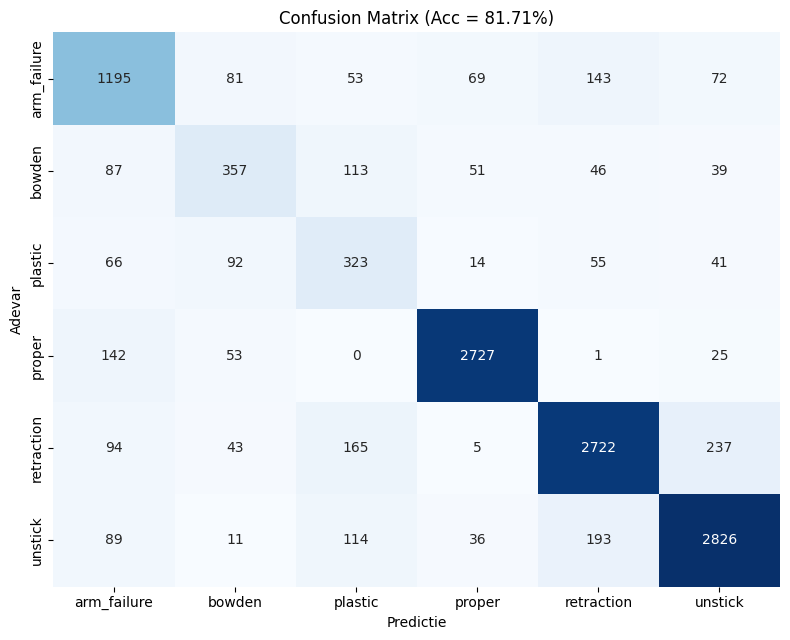

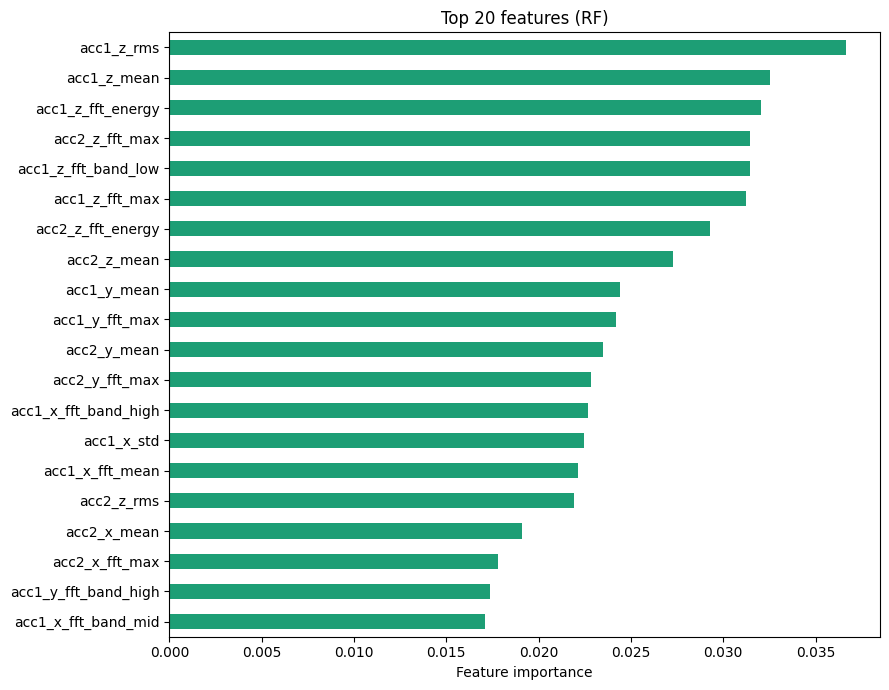

[OK] Model final pregatit. De aici incolo: 90 features.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt, seaborn as sns, pandas as pd, os

# Parametri optimi gasiti anterior prin GridSearchCV (nu mai re-rulam cautarea)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_final = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=1,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)

scores = cross_val_score(rf_final, X_full, y_full_enc, groups=groups_full,
                         cv=sgkf, scoring='accuracy', n_jobs=-1)
print(f'Acuratete block-CV: {scores.mean()*100:.2f}% +/- {scores.std()*100:.2f}%')

y_pred_full = cross_val_predict(rf_final, X_full, y_full_enc,
                                groups=groups_full, cv=sgkf, n_jobs=-1)
print(classification_report(y_full_enc, y_pred_full,
                            target_names=le_full.classes_, digits=3))

# figuri (suprascriu fisierele existente)
cm = confusion_matrix(y_full_enc, y_pred_full)
cm_df = pd.DataFrame(cm, index=le_full.classes_, columns=le_full.classes_)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title(f'Confusion Matrix (Acc = {scores.mean()*100:.2f}%)')
ax.set_xlabel('Predictie'); ax.set_ylabel('Adevar')
plt.tight_layout(); plt.savefig(os.path.join(GRAFICE_DIR,'confusion_matrix_final.png'), dpi=150); plt.show()

rf_final.fit(X_full, y_full_enc)
importances = pd.Series(rf_final.feature_importances_, index=FEATURE_NAMES)
top20 = importances.sort_values().tail(20)
fig, ax = plt.subplots(figsize=(9,7))
top20.plot(kind='barh', color='#1D9E75', ax=ax)
ax.set_title('Top 20 features (RF)'); ax.set_xlabel('Feature importance')
plt.tight_layout(); plt.savefig(os.path.join(GRAFICE_DIR,'feature_importance.png'), dpi=150); plt.show()

# unificare: tot ce urmeaza foloseste 90 features
X_blk, y_blk_enc, groups_blk, le_blk, y_blk = X_full, y_full_enc, groups_full, le_full, y_full
print('[OK] Model final pregatit. De aici incolo: 90 features.')

# Experiment A: influența poziției senzorului


Influenta pozitiei senzorului (StratifiedGroupKFold, 5 folduri)
Doar senzor 1 (pat)      | 45 features | 77.52% +/- 8.37%
Doar senzor 2 (cap)      | 45 features | 55.42% +/- 5.07%
Ambii senzori (actual)   | 90 features | 81.71% +/- 7.04%


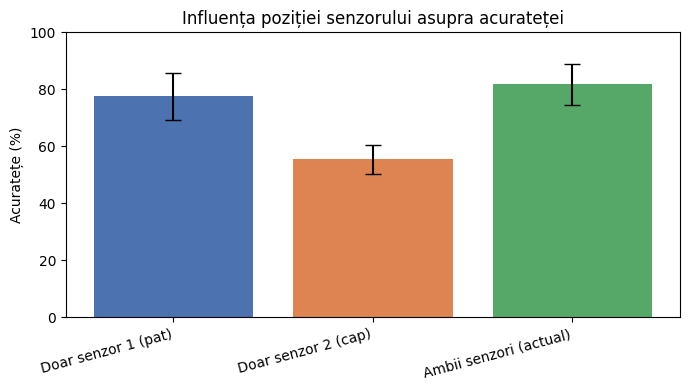

In [ ]:
# === Experiment A: influența poziției senzorului ===
# acc1 = senzor pe pat (col. 0:45), acc2 = senzor pe capul de printare (col. 45:90)
from sklearn.base import clone
import matplotlib.pyplot as plt

config_axe = {
    'Doar senzor 1 (pat)':    slice(0, 45),
    'Doar senzor 2 (cap)':    slice(45, 90),
    'Ambii senzori (actual)': slice(0, 90),
}

rezultate_senzori = {}
print('Influenta pozitiei senzorului (StratifiedGroupKFold, 5 folduri)')
print('=' * 60)
for nume, cols in config_axe.items():
    X_sub = X_full[:, cols]
    model = clone(rf_final)
    sc = cross_val_score(model, X_sub, y_full_enc, groups=groups_full,
                         cv=sgkf, scoring='accuracy', n_jobs=-1)
    rezultate_senzori[nume] = (sc.mean() * 100, sc.std() * 100, X_sub.shape[1])
    print(f'{nume:24s} | {X_sub.shape[1]:2d} features | '
          f'{sc.mean()*100:5.2f}% +/- {sc.std()*100:.2f}%')

# --- figura pentru lucrare ---
nume  = list(rezultate_senzori.keys())
medii = [rezultate_senzori[n][0] for n in nume]
erori = [rezultate_senzori[n][1] for n in nume]

plt.figure(figsize=(7, 4))
plt.bar(range(len(nume)), medii, yerr=erori, capsize=6,
        color=['#4C72B0', '#DD8452', '#55A868'])
plt.xticks(range(len(nume)), nume, rotation=15, ha='right')
plt.ylabel('Acuratețe (%)')
plt.title('Influența poziției senzorului asupra acurateței')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICE_DIR, 'experiment_senzori.png'), dpi=150)
plt.show()

# Experiment: detectie binara (normal vs defect)

> Add blockquote



In [ ]:
# === Experiment: detectie binara (normal vs defect) ===
from sklearn.metrics import confusion_matrix

y_binar = np.where(y_full == 'proper', 'normal', 'defect')
le_bin  = LabelEncoder()
y_bin_enc = le_bin.fit_transform(y_binar)

model = clone(rf_final)
acc = cross_val_score(model, X_full, y_bin_enc, groups=groups_full,
                      cv=sgkf, scoring='accuracy', n_jobs=-1)
bal = cross_val_score(model, X_full, y_bin_enc, groups=groups_full,
                      cv=sgkf, scoring='balanced_accuracy', n_jobs=-1)

print('Detectie binara (normal vs defect) - StratifiedGroupKFold')
print(f'  Accuracy:          {acc.mean()*100:.2f}% +/- {acc.std()*100:.2f}%')
print(f'  Balanced accuracy: {bal.mean()*100:.2f}% +/- {bal.std()*100:.2f}%')

y_pred_bin = cross_val_predict(model, X_full, y_bin_enc, groups=groups_full,
                               cv=sgkf, n_jobs=-1)
cm_bin = confusion_matrix(y_bin_enc, y_pred_bin)
print('\nMatrice de confuzie (binar):')
print(pd.DataFrame(cm_bin, index=le_bin.classes_, columns=le_bin.classes_))

Detectie binara (normal vs defect) - StratifiedGroupKFold
  Accuracy:          96.49% +/- 2.86%
  Balanced accuracy: 94.70% +/- 4.40%

Matrice de confuzie (binar):
        defect  normal
defect    9331     101
normal     354    2594


## 11. Comparația algoritmilor (validare pe grupuri)

Cinci algoritmi sunt antrenați și comparați pe aceleași date și cu același protocol de validare (Block-CV), pentru a produce tabelul comparativ și a justifica alegerea modelului.

Algoritmi comparați:
- **Random Forest** — modelul propus
- **Gradient Boosting** — alt ansamblu de arbori
- **SVM (RBF)** — metodă neliniară clasică
- **k-NN (k=5)** — referință simplă
- **Logistic Regression** — referință liniară

Evaluez Random Forest...
Evaluez Gradient Boosting...
Evaluez SVM (RBF)...
Evaluez k-NN (k=5)...
Evaluez Logistic Regression...

REZULTATE COMPARATIVE (StratifiedGroupKFold, 5 folds)
              Model  Accuracy (%)  Std (%)  Timp CV (s)
          SVM (RBF)     82.847847 7.697354    14.584482
      Random Forest     81.707098 7.042502   146.825629
  Gradient Boosting     80.992461 7.663489  1196.610975
Logistic Regression     76.749791 6.781465     6.951563
         k-NN (k=5)     70.336852 5.975463     2.696332


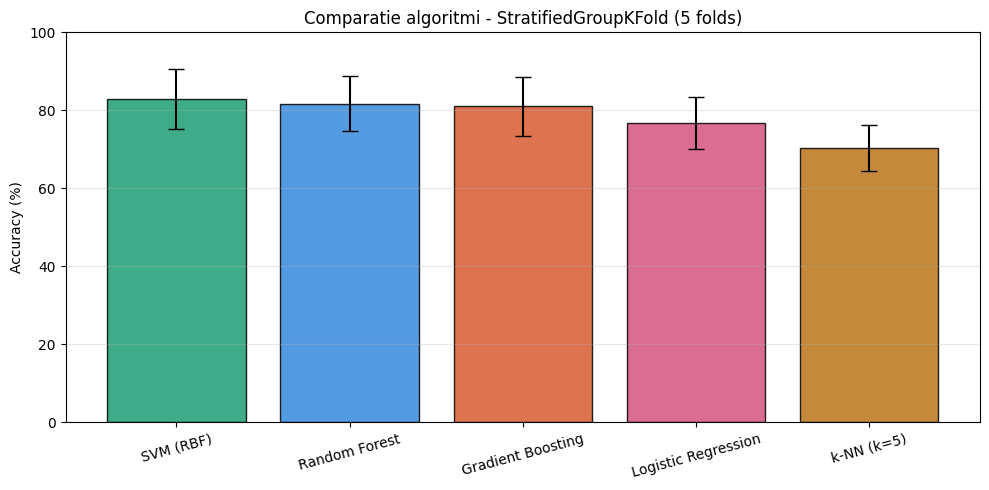

In [ ]:
modele = {
    'Random Forest': rf_final,
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM (RBF)': Pipeline([('sc', StandardScaler()),
                          ('clf', SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE))]),
    'k-NN (k=5)': Pipeline([('sc', StandardScaler()),
                            ('clf', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))]),
    'Logistic Regression': Pipeline([('sc', StandardScaler()),
                                     ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
}

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rezultate = []

for nume, model in modele.items():
    print(f'Evaluez {nume}...')
    t0 = time.time()
    scores = cross_val_score(model, X_blk, y_blk_enc, groups=groups_blk,
                             cv=sgkf, scoring='accuracy', n_jobs=-1)
    rezultate.append({
        'Model': nume,
        'Accuracy (%)': scores.mean() * 100,
        'Std (%)': scores.std() * 100,
        'Timp CV (s)': time.time() - t0,
    })

rez_df = pd.DataFrame(rezultate).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
print('\n' + '='*60)
print('REZULTATE COMPARATIVE (StratifiedGroupKFold, 5 folds)')
print('='*60)
print(rez_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(rez_df['Model'], rez_df['Accuracy (%)'],
       yerr=rez_df['Std (%)'], capsize=6,
       color=['#1D9E75', '#378ADD', '#D85A30', '#D4537E', '#BA7517'],
       edgecolor='black', alpha=0.85)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparatie algoritmi - StratifiedGroupKFold (5 folds)', fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICE_DIR, 'comparatie_algoritmi.png'), dpi=150)
plt.show()

## 12. Vizualizare t-SNE — separabilitatea claselor

Reduc cele 90 dimensiuni la 2D pentru vizualizare. Punctele apropiate în 2D = ferestre similare. Dacă clasele formează **clustere distincte**, modelul ML poate să le distingă. Dacă se amestecă, problema e dificilă.

Calculez t-SNE pe 3000 ferestre (1-2 min)...


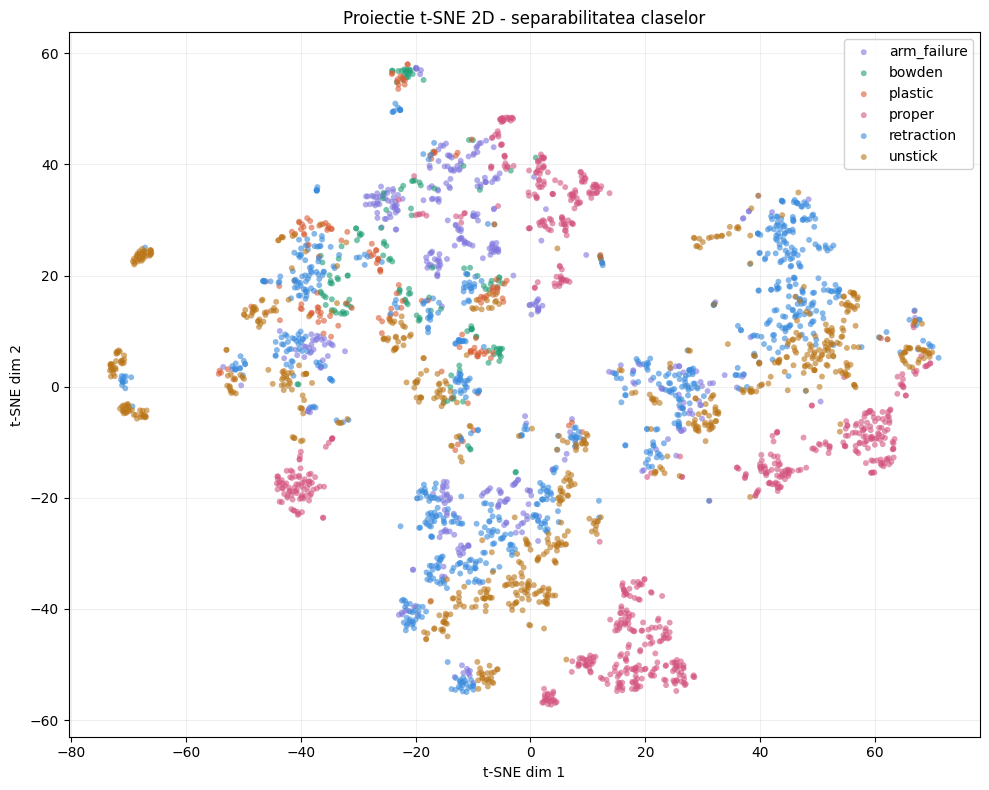

In [ ]:
n_sample = min(3000, len(X_blk))
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_blk), size=n_sample, replace=False)
X_scaled = StandardScaler().fit_transform(X_blk[idx])

print(f'Calculez t-SNE pe {n_sample} ferestre (1-2 min)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE,
            init='pca', learning_rate='auto')
X_2d = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
for cls in le_blk.classes_:
    mask = (y_blk[idx] == cls)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=CULORI[cls], label=cls, alpha=0.6, s=18, edgecolor='none')
ax.set_title('Proiectie t-SNE 2D - separabilitatea claselor', fontsize=12)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(loc='best', framealpha=0.9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICE_DIR, 'tsne_2d.png'), dpi=150)
plt.show()

## 13. Curba de învățare

Arată evoluția acurateței în funcție de numărul de exemple de antrenare. Util ca să știi dacă:
- Curba **continua să urce** → mai multe date ar ajuta
- Curba e **în platou** → modelul a saturat, nu mai are nevoie de date

Calculez learning curve (2-3 min)...


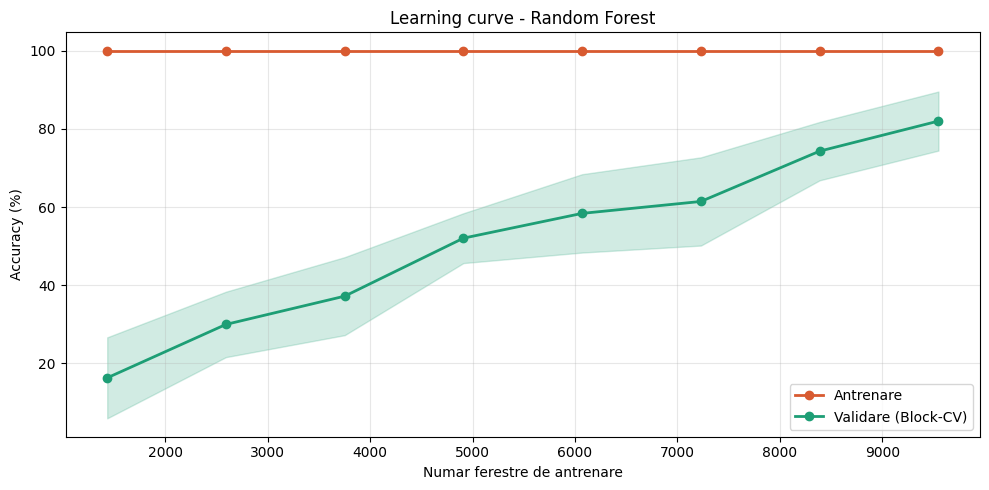

In [ ]:
train_sizes = np.linspace(0.15, 1.0, 8)
print('Calculez learning curve (2-3 min)...')
ts, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    X_blk, y_blk_enc, groups=groups_blk, cv=sgkf,
    train_sizes=train_sizes, scoring='accuracy', n_jobs=-1
)
train_m, train_s = train_scores.mean(1) * 100, train_scores.std(1) * 100
val_m, val_s = val_scores.mean(1) * 100, val_scores.std(1) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts, train_m, 'o-', color='#D85A30', label='Antrenare', linewidth=2)
ax.fill_between(ts, train_m - train_s, train_m + train_s, alpha=0.2, color='#D85A30')
ax.plot(ts, val_m, 'o-', color='#1D9E75', label='Validare (Block-CV)', linewidth=2)
ax.fill_between(ts, val_m - val_s, val_m + val_s, alpha=0.2, color='#1D9E75')
ax.set_xlabel('Numar ferestre de antrenare')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Learning curve - Random Forest', fontsize=12)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICE_DIR, 'learning_curve.png'), dpi=150)
plt.show()

## 14. Curbe ROC — calitatea predicției pe fiecare clasă

Curba ROC arată trade-off-ul între detecții corecte și false alarme. Pentru fiecare clasă calculez AUC (Area Under Curve):
- AUC = 1.0 → perfect
- AUC = 0.5 → ghicit aleator

Utilizez schema **One-vs-Rest** (fiecare clasă vs restul).

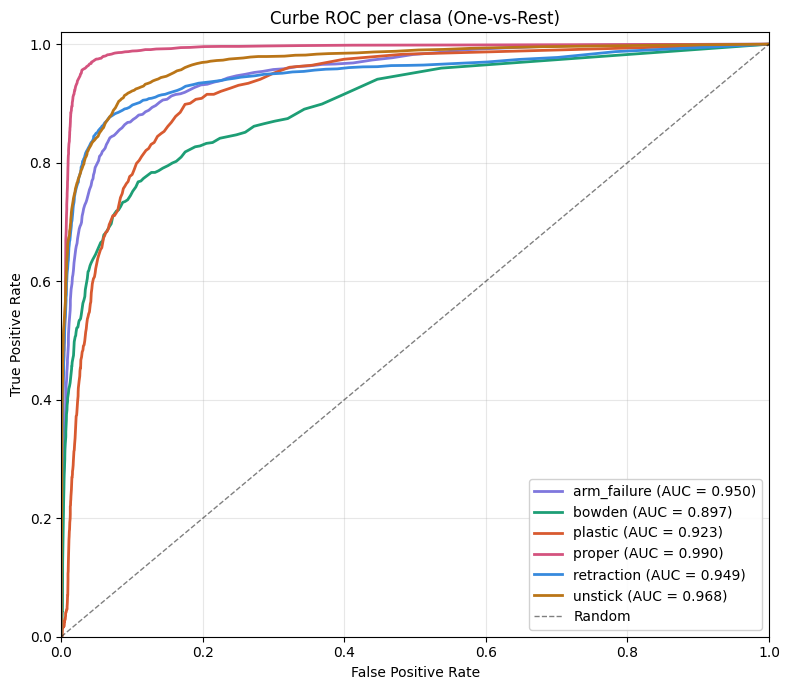

In [ ]:
y_proba = cross_val_predict(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    X_blk, y_blk_enc, groups=groups_blk, cv=sgkf,
    method='predict_proba', n_jobs=-1
)
y_bin = label_binarize(y_blk_enc, classes=list(range(len(le_blk.classes_))))

fig, ax = plt.subplots(figsize=(8, 7))
culori_list = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E', '#378ADD', '#BA7517']
for i, cls in enumerate(le_blk.classes_):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=culori_list[i], lw=2,
            label=f'{cls} (AUC = {a:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curbe ROC per clasa (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(GRAFICE_DIR, 'roc_curves.png'), dpi=150)
plt.show()

## 15. Export modele pentru deployment

Pasul final antrenează și salvează **două modele**, plus un set de date pentru demonstrator. Fiecare fișier are un rol clar:

### Modelul de demo (pentru replay)
- `model_demo.joblib` — antrenat doar pe blocurile 0-8 din fiecare clasă (~90% din date)
- blocul 9 rămâne nevăzut de model și este salvat în `demo_set.csv`
- folosit pentru un demonstrator pe date din dataset pe care modelul nu le-a văzut (predicții cinstite)

### Modelul final (pentru utilizare)
- `model_full.joblib` — antrenat pe **toate** datele (~12.380 ferestre)
- folosit în aplicația care citește live de la senzor
- datele de la senzorul fizic sunt noi (nu erau în setul Szydło), deci evaluarea rămâne cinstită

### Fișiere comune (folosite de ambele scripturi)
- `scaler.joblib` — standardizatorul atașat modelului
- `label_encoder.joblib` — traducătorul de la index la nume de clasă

### Set de demonstrare
- `demo_set.csv` — caracteristicile celor ~10% de date nevăzute de `model_demo`, plus etichetele reale; aplicația de replay citește acest fișier.

**Important:** acuratețea raportată în lucrare rămâne **81,71%**, obținută prin Block-CV. Cele două modele de aici sunt destinate demonstratorului/utilizării, nu raportării.

In [ ]:
EXPORT_DIR = 'export'
os.makedirs(EXPORT_DIR, exist_ok=True)

is_demo_block = np.array([g.endswith('_b9') for g in groups_full])

X_train_demo = X_full[~is_demo_block]
y_train_demo = y_full_enc[~is_demo_block]

X_holdout = X_full[is_demo_block]
y_holdout = y_full_enc[is_demo_block]

print(f'Train pentru model_demo:  {len(X_train_demo)} ferestre (blocurile 0-8)')
print(f'Demo set (holdout):       {len(X_holdout)} ferestre (blocul 9)')

scaler_demo = StandardScaler()
X_train_demo_scaled = scaler_demo.fit_transform(X_train_demo)

rf_demo = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=1,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
)
rf_demo.fit(X_train_demo_scaled, y_train_demo)

X_holdout_scaled = scaler_demo.transform(X_holdout)
acc_holdout = accuracy_score(y_holdout, rf_demo.predict(X_holdout_scaled))
print(f'Acuratete model_demo pe holdout (blocul 9):  {acc_holdout*100:.2f}%')

joblib.dump(rf_demo, os.path.join(EXPORT_DIR, 'model_demo.joblib'))
joblib.dump(scaler_demo, os.path.join(EXPORT_DIR, 'scaler.joblib'))

demo_df = pd.DataFrame(X_holdout, columns=FEATURE_NAMES)
demo_df['label_true'] = le_full.inverse_transform(y_holdout)
demo_df['label_idx'] = y_holdout
demo_df.to_csv(os.path.join(EXPORT_DIR, 'demo_set.csv'), index=False)
print(f'Salvat demo_set.csv: {len(demo_df)} ferestre, {len(demo_df.columns)} coloane')

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

rf_full = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=1,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
)
rf_full.fit(X_full_scaled, y_full_enc)

joblib.dump(rf_full, os.path.join(EXPORT_DIR, 'model_full.joblib'))
joblib.dump(scaler_full, os.path.join(EXPORT_DIR, 'scaler_full.joblib'))
joblib.dump(le_full, os.path.join(EXPORT_DIR, 'label_encoder.joblib'))

with open(os.path.join(EXPORT_DIR, 'feature_names.txt'), 'w') as f:
    f.write('\n'.join(FEATURE_NAMES))

size_demo_mb = os.path.getsize(os.path.join(EXPORT_DIR, 'model_demo.joblib')) / (1024**2)
size_full_mb = os.path.getsize(os.path.join(EXPORT_DIR, 'model_full.joblib')) / (1024**2)

n_trials = 200
t0 = time.time()
for _ in range(n_trials):
    rf_full.predict(X_full_scaled[:1])
t_single_ms = (time.time() - t0) / n_trials * 1000

print('\n' + '=' * 60)
print('REZUMAT EXPORT')
print('=' * 60)
print(f'Folder: {EXPORT_DIR}/')
print(f'\nFisiere create:')
print(f'  model_demo.joblib       ({size_demo_mb:.2f} MB) - antrenat pe blocurile 0-8')
print(f'  model_full.joblib       ({size_full_mb:.2f} MB) - antrenat pe toate datele')
print(f'  scaler.joblib                  - pentru model_demo')
print(f'  scaler_full.joblib             - pentru model_full')
print(f'  label_encoder.joblib           - pentru ambele modele')
print(f'  demo_set.csv             ({len(demo_df)} ferestre, 90 features + labels)')
print(f'  feature_names.txt        - ordinea exacta a celor 90 features')
print(f'\nLatenta predictie (single window): {t_single_ms:.3f} ms')
print(f'\nDescarca tot folderul "export/" si pune-l langa scripturile locale.')

Train pentru model_demo:  11115 ferestre (blocurile 0-8)
Demo set (holdout):       1265 ferestre (blocul 9)
Acuratete model_demo pe holdout (blocul 9):  75.81%
Salvat demo_set.csv: 1265 ferestre, 92 coloane

REZUMAT EXPORT
Folder: export/

Fisiere create:
  model_demo.joblib       (56.83 MB) - antrenat pe blocurile 0-8
  model_full.joblib       (65.51 MB) - antrenat pe toate datele
  scaler.joblib                  - pentru model_demo
  scaler_full.joblib             - pentru model_full
  label_encoder.joblib           - pentru ambele modele
  demo_set.csv             (1265 ferestre, 90 features + labels)
  feature_names.txt        - ordinea exacta a celor 90 features

Latenta predictie (single window): 81.261 ms

Descarca tot folderul "export/" si pune-l langa scripturile locale.


## 16. Descărcare arhivă export (rulează doar în Colab)

Celula de mai jos împachetează folderul `export/` într-un singur ZIP și îl descarcă automat în `Downloads` pe Windows. Dezarhivezi local și pui folderul lângă scripturile Python.

Dacă rulezi notebook-ul în Jupyter local (nu Colab), sari peste această celulă — fișierele sunt deja salvate în `export/` lângă notebook.

In [ ]:
import shutil

zip_path = shutil.make_archive('export', 'zip', EXPORT_DIR)
print(f'Arhiva creata: {zip_path}')
print(f'Marime: {os.path.getsize(zip_path) / (1024**2):.1f} MB')

try:
    from google.colab import files
    files.download(zip_path)
    print('Descarcare initiata. Dezarhiveaza in c:\\Users\\ispas\\Downloads\\licenta_demo\\')
except ImportError:
    print('Nu esti pe Colab. Arhiva e in folderul curent, copiaz-o manual.')

Arhiva creata: /content/export.zip
Marime: 32.1 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarcare initiata. Dezarhiveaza in c:\Users\ispas\Downloads\licenta_demo\


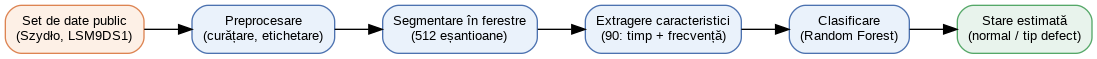

In [ ]:
from graphviz import Digraph
from IPython.display import Image
import os

dot = Digraph('arhitectura', format='png')
dot.attr(rankdir='LR', fontname='Helvetica', fontsize='11')
dot.attr('node', shape='box', style='rounded,filled',
         fontname='Helvetica', fontsize='10', fillcolor='#EAF2FB', color='#4C72B0')

dot.node('ds',   'Set de date public\n(Szydło, LSM9DS1)', fillcolor='#FDF0E6', color='#DD8452')
dot.node('prep', 'Preprocesare\n(curățare, etichetare)')
dot.node('seg',  'Segmentare în ferestre\n(512 eșantioane)')
dot.node('feat', 'Extragere caracteristici\n(90: timp + frecvență)')
dot.node('clf',  'Clasificare\n(Random Forest)')
dot.node('out',  'Stare estimată\n(normal / tip defect)', fillcolor='#E8F3EC', color='#55A868')

dot.edge('ds', 'prep')
dot.edge('prep', 'seg')
dot.edge('seg', 'feat')
dot.edge('feat', 'clf')
dot.edge('clf', 'out')

out_path = os.path.join(GRAFICE_DIR, 'arhitectura')
dot.render(out_path, cleanup=True)
Image(out_path + '.png')

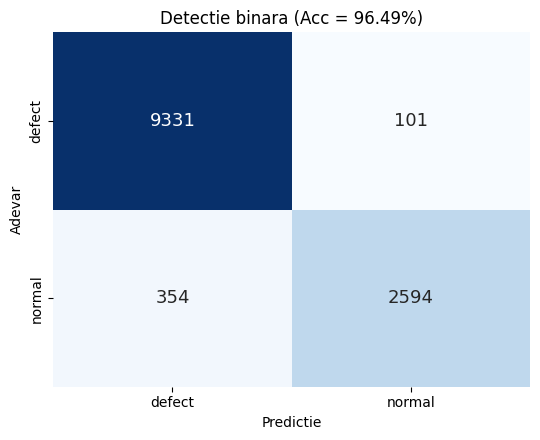

In [ ]:
# === Heatmap matrice de confuzie binara ===
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(pd.DataFrame(cm_bin, index=le_bin.classes_, columns=le_bin.classes_),
            annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={'size': 13}, ax=ax)
ax.set_title(f'Detectie binara (Acc = {acc.mean()*100:.2f}%)', fontsize=12)
ax.set_xlabel('Predictie')
ax.set_ylabel('Adevar')
plt.tight_layout()
plt.savefig(os.path.join(GRAFICE_DIR, 'confusion_matrix_binar.png'), dpi=150)
plt.show()

In [ ]:
# === Model pentru prototip cu UN SINGUR senzor (3 axe / 45 features) ===
import os, joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

EXPORT_DIR = 'export'
os.makedirs(EXPORT_DIR, exist_ok=True)

X_s1 = X_full[:, 0:45]                 # senzor 1 (pat): acc1_x/y/z = 45 features
FEATURE_NAMES_S1 = FEATURE_NAMES[:45]

rf_s1 = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=1,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
)

# verificare Block-CV (ar trebui ~77-78%, ca in sectiunea 5.5)
sc = cross_val_score(rf_s1, X_s1, y_full_enc, groups=groups_full,
                     cv=sgkf, scoring='accuracy', n_jobs=-1)
print(f'Model 1 senzor (45 features): {sc.mean()*100:.2f}% +/- {sc.std()*100:.2f}%')

scaler_s1 = StandardScaler()
X_s1_scaled = scaler_s1.fit_transform(X_s1)
rf_s1.fit(X_s1_scaled, y_full_enc)

joblib.dump(rf_s1,     os.path.join(EXPORT_DIR, 'model_s1.joblib'))
joblib.dump(scaler_s1, os.path.join(EXPORT_DIR, 'scaler_s1.joblib'))
joblib.dump(le_full,   os.path.join(EXPORT_DIR, 'label_encoder.joblib'))
with open(os.path.join(EXPORT_DIR, 'feature_names_s1.txt'), 'w') as f:
    f.write('\n'.join(FEATURE_NAMES_S1))

print('Export OK: model_s1.joblib, scaler_s1.joblib, feature_names_s1.txt')

Model 1 senzor (45 features): 77.52% +/- 8.37%
Export OK: model_s1.joblib, scaler_s1.joblib, feature_names_s1.txt


In [ ]:
import shutil
from google.colab import files

shutil.make_archive('export', 'zip', 'export')
files.download('export.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# === Model BINAR (normal vs defect) pe UN SINGUR senzor (45 features) ===
import os, joblib, numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score

EXPORT_DIR = 'export'
os.makedirs(EXPORT_DIR, exist_ok=True)

X_s1 = X_full[:, 0:45]
y_binar = np.where(y_full == 'proper', 'normal', 'defect')
le_bin = LabelEncoder()
y_bin_enc = le_bin.fit_transform(y_binar)

rf_s1_bin = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=1,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
)
acc = cross_val_score(rf_s1_bin, X_s1, y_bin_enc, groups=groups_full,
                      cv=sgkf, scoring='accuracy', n_jobs=-1)
bal = cross_val_score(rf_s1_bin, X_s1, y_bin_enc, groups=groups_full,
                      cv=sgkf, scoring='balanced_accuracy', n_jobs=-1)
print(f'Binar 1 senzor (45 feat): acc {acc.mean()*100:.2f}%  bal {bal.mean()*100:.2f}%')

scaler_s1_bin = StandardScaler()
rf_s1_bin.fit(scaler_s1_bin.fit_transform(X_s1), y_bin_enc)

joblib.dump(rf_s1_bin,     os.path.join(EXPORT_DIR, 'model_s1_bin.joblib'))
joblib.dump(scaler_s1_bin, os.path.join(EXPORT_DIR, 'scaler_s1_bin.joblib'))
joblib.dump(le_bin,        os.path.join(EXPORT_DIR, 'label_encoder_bin.joblib'))
print('Export OK: model_s1_bin, scaler_s1_bin, label_encoder_bin')

Binar 1 senzor (45 feat): acc 96.40%  bal 94.66%
Export OK: model_s1_bin, scaler_s1_bin, label_encoder_bin


In [ ]:
from google.colab import files
files.download('export/model_s1_bin.joblib')
files.download('export/scaler_s1_bin.joblib')
files.download('export/label_encoder_bin.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =====================================================================
# STUDIU 1 - Ablation: contributia domeniilor de caracteristici
# (doar timp / doar frecventa / ambele) - validare pe grupuri
# =====================================================================
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

idx_time = [a*15 + i for a in range(6) for i in range(0, 8)]    # 48 (primele 8/axa)
idx_freq = [a*15 + i for a in range(6) for i in range(8, 15)]   # 42 (ultimele 7/axa)
config_ablation = {
    'Doar timp (48)':      idx_time,
    'Doar frecventa (42)': idx_freq,
    'Ambele (90)':         list(range(90)),
}

print('Ablation (StratifiedGroupKFold, 5 folduri)')
print('=' * 50)
for nume, cols in config_ablation.items():
    sc = cross_val_score(clone(rf_final), X_full[:, cols], y_full_enc,
                         groups=groups_full, cv=sgkf, scoring='accuracy', n_jobs=-1)
    print(f'{nume:22s}: {sc.mean()*100:.2f}% +/- {sc.std()*100:.2f}%')


Ablation (StratifiedGroupKFold, 5 folduri)
Doar timp (48)        : 81.33% +/- 7.36%
Doar frecventa (42)   : 80.94% +/- 6.98%
Ambele (90)           : 81.71% +/- 7.04%


In [ ]:
# =====================================================================
# STUDIU 2 - Influenta numarului de arbori (Random Forest)
# =====================================================================
import time as _t
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

print('Numar de arbori (StratifiedGroupKFold, 5 folduri)')
print('=' * 50)
for n in [50, 100, 200, 300, 500]:
    m = RandomForestClassifier(n_estimators=n, max_depth=None, min_samples_leaf=1,
                               class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
    t0 = _t.time()
    sc = cross_val_score(m, X_full, y_full_enc, groups=groups_full, cv=sgkf,
                         scoring='accuracy', n_jobs=-1)
    print(f'{n:4d} arbori: {sc.mean()*100:.2f}% +/- {sc.std()*100:.2f}%  |  {_t.time()-t0:.1f}s')


Numar de arbori (StratifiedGroupKFold, 5 folduri)
  50 arbori: 80.95% +/- 7.54%  |  24.4s
 100 arbori: 81.67% +/- 7.01%  |  49.9s
 200 arbori: 81.59% +/- 7.13%  |  97.3s
 300 arbori: 81.71% +/- 7.04%  |  142.9s
 500 arbori: 81.56% +/- 7.24%  |  244.1s


In [ ]:
# =====================================================================
# STUDIU 3 - Influenta dimensiunii ferestrei (256 / 512 / 1024)
# Reextrage caracteristicile pentru fiecare dimensiune (dureaza mai mult)
# =====================================================================
import numpy as np, pandas as pd
from scipy.stats import skew, kurtosis
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score

def feat_fereastra(w):
    f = []
    for ax in range(6):
        d = w[:, ax]; ab = np.abs(d); rms = np.sqrt(np.mean(d**2))
        fv = np.abs(np.fft.rfft(d))
        f += [np.mean(d), np.std(d), ab.max(), d.min(), rms, kurtosis(d),
              ab.max()/(rms+1e-9), skew(d),
              np.mean(fv), np.max(fv), float(np.argmax(fv)), np.sum(fv**2),
              np.sum(fv[:10]), np.sum(fv[10:50]), np.sum(fv[50:])]
    return f

def construieste(W, n_blocks=10):
    X, y, g = [], [], []
    for label in df_all['label'].unique():
        sub = df_all[df_all['label'] == label][AXES].copy()
        for c in AXES:
            sub[c] = pd.to_numeric(sub[c], errors='coerce')
        sub = sub.dropna().values.astype(np.float64)
        starts = list(range(0, len(sub) - W, W))
        wpb = max(1, len(starts) // n_blocks)
        for wi, s in enumerate(starts):
            X.append(feat_fereastra(sub[s:s+W])); y.append(label)
            g.append(f'{label}_b{min(wi//wpb, n_blocks-1)}')
    return np.array(X), np.array(y), np.array(g)

print('Dimensiunea ferestrei (StratifiedGroupKFold, 5 folduri)')
print('=' * 50)
for W in [256, 512, 1024]:
    Xw, yw, gw = construieste(W)
    yenc = LabelEncoder().fit_transform(yw)
    sc = cross_val_score(clone(rf_final), Xw, yenc, groups=gw, cv=sgkf,
                         scoring='accuracy', n_jobs=-1)
    print(f'Fereastra {W:4d} ({W/200:.2f}s): {len(Xw):5d} ferestre, '
          f'acc {sc.mean()*100:.2f}% +/- {sc.std()*100:.2f}%')


Dimensiunea ferestrei (StratifiedGroupKFold, 5 folduri)
Fereastra  256 (1.28s): 24761 ferestre, acc 76.22% +/- 9.96%
Fereastra  512 (2.56s): 12380 ferestre, acc 81.71% +/- 7.04%
Fereastra 1024 (5.12s):  6188 ferestre, acc 83.66% +/- 5.63%


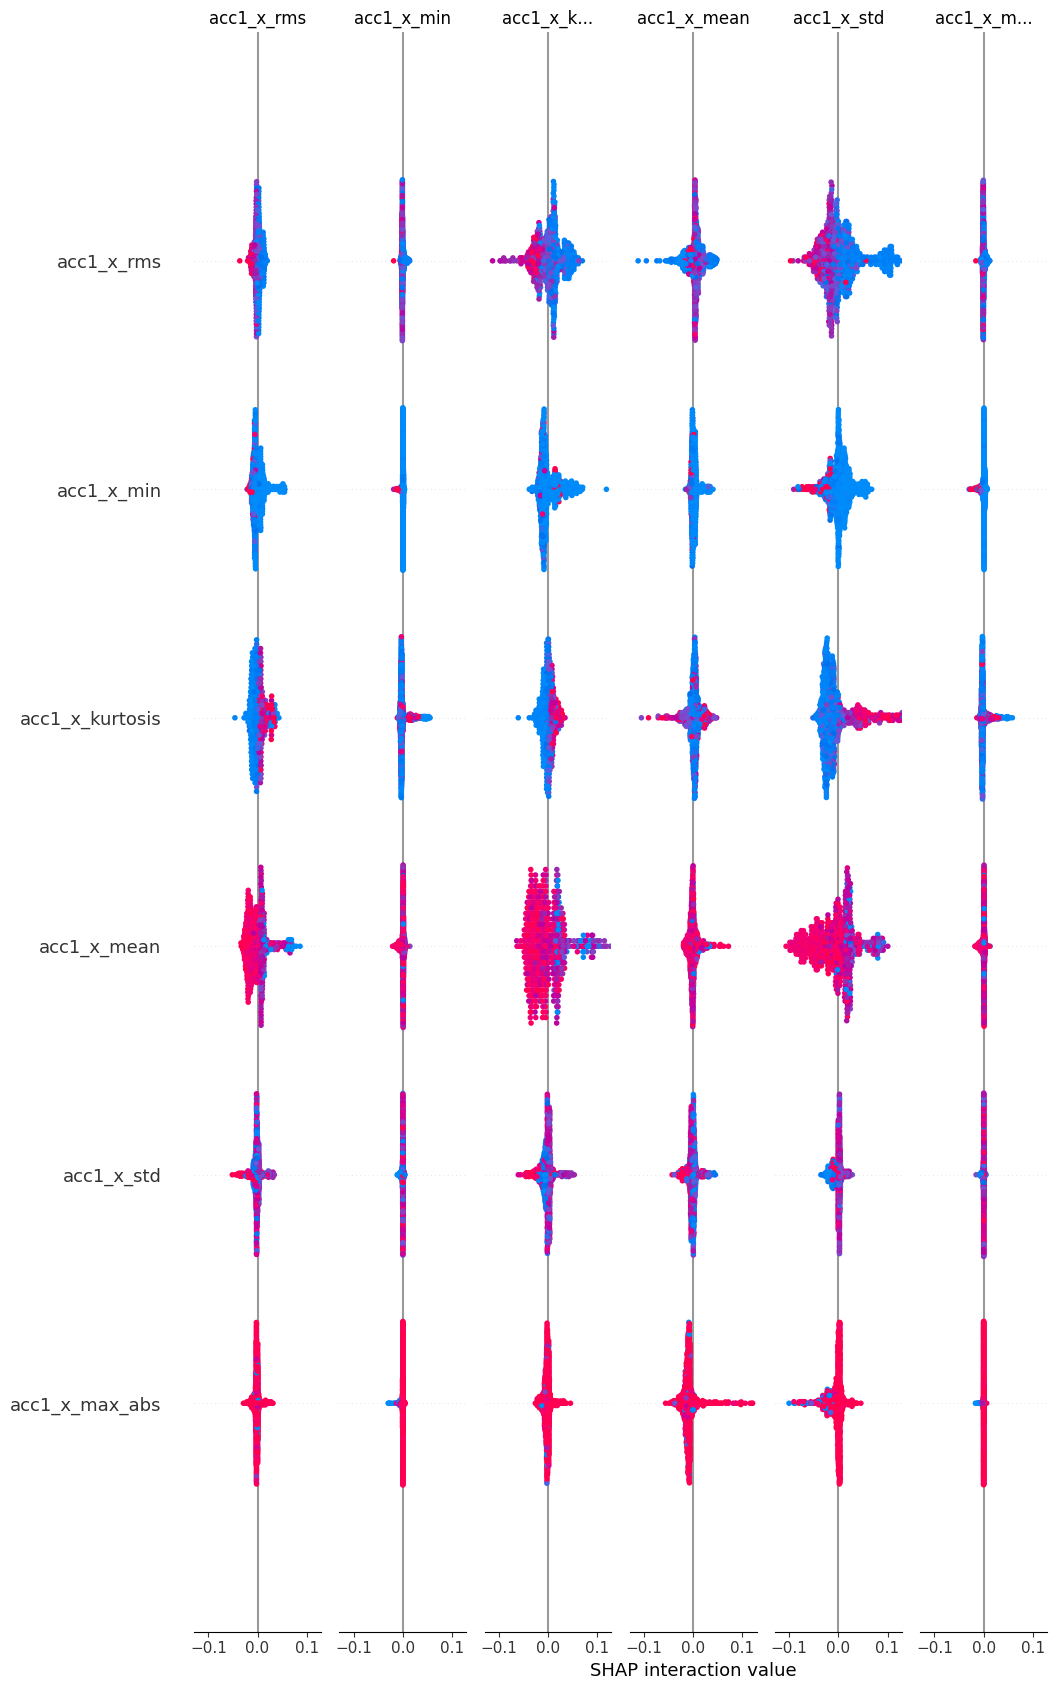

Salvat shap_summary.png


In [ ]:
# =====================================================================
# STUDIU 4 (OPTIONAL) - SHAP: interpretabilitate
# Se calculeaza pe un esantion de ferestre, ca sa fie rapid.
# Daca da eroare la instalare/versiune, poate fi sarit - nu e obligatoriu.
# =====================================================================
!pip -q install shap
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

# model dedicat (arborii nu necesita scalare)
rf_shap = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=1,
                                 class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_shap.fit(X_full, y_full_enc)

# esantion pentru viteza
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_full), size=min(800, len(X_full)), replace=False)
X_sample = X_full[idx]

explainer = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_sample)

# summary plot global (importanta + directie), primele 20 caracteristici
shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_NAMES,
                  show=False, max_display=20)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat shap_summary.png')


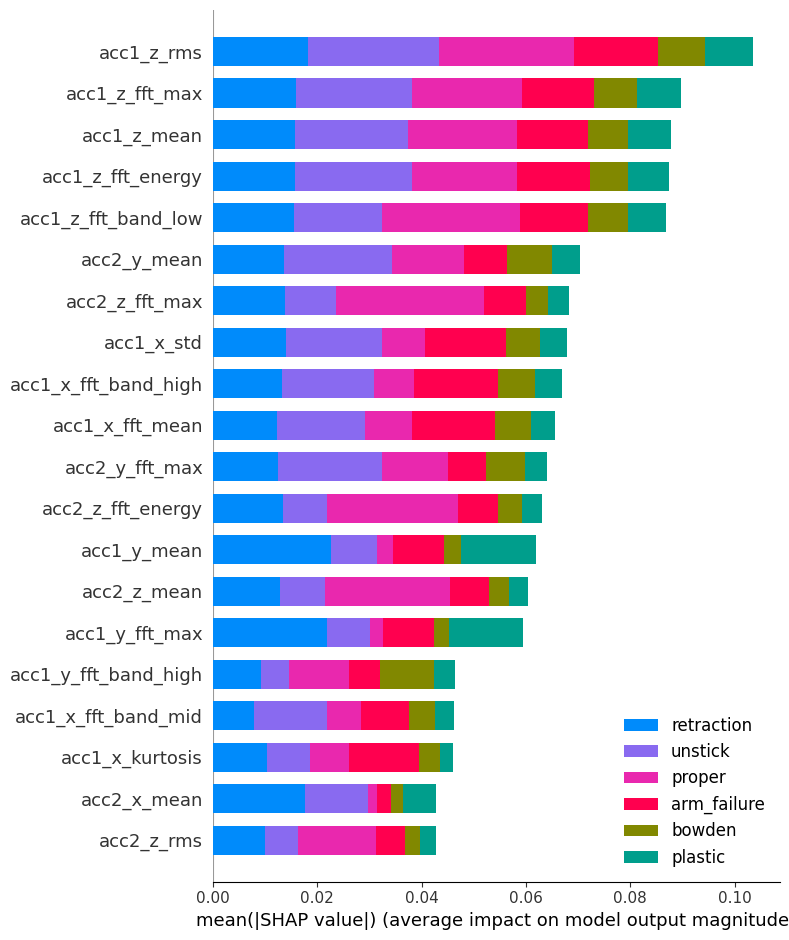

Salvat shap_bar.png


In [ ]:
!pip -q install shap
import shap, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

rf_shap = RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_leaf=1,
                                 class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_shap.fit(X_full, y_full_enc)

rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_full), size=min(800, len(X_full)), replace=False)
X_sample = X_full[idx]

explainer = shap.TreeExplainer(rf_shap)
sv = explainer.shap_values(X_sample)

shap.summary_plot(sv, X_sample, feature_names=FEATURE_NAMES,
                  plot_type='bar', max_display=20, show=False,
                  class_names=list(le_full.classes_))
plt.tight_layout(); plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight'); plt.show()
print('Salvat shap_bar.png')

In [ ]:
import os, time, joblib
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

sc = StandardScaler().fit(X_full)
m = clone(rf_final); m.fit(sc.transform(X_full), y_full_enc)
x1 = sc.transform(X_full[:1])

N = 200; t0 = time.time()
for _ in range(N): m.predict(x1)
print(f'Latenta per fereastra: {(time.time()-t0)/N*1000:.2f} ms')

joblib.dump(m, 'tmp.joblib')
print(f'Dimensiune model: {os.path.getsize("tmp.joblib")/1e6:.1f} MB')
print(f'Arbori: {m.n_estimators}, noduri totale: {sum(t.tree_.node_count for t in m.estimators_)}')

Latenta per fereastra: 77.53 ms
Dimensiune model: 68.7 MB
Arbori: 300, noduri totale: 612168
